In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import skimage as ski
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score

In [2]:
os.chdir(r"C:\Users\TOMLU\Desktop\Data3888\individual")

In [3]:
RANDOM_SEED = 3888

# adjust this based on what strategy has been used to produce train/test folds + what image size
# code assumes image_dir/folds/classes/[images here] structure
UNCENTERED_DIR = os.path.join("projectdata", "images", "uncentred_ternary_100_stratified4fold_1000per_seed3888")
# can change fold list 
FOLDS = ["Q1", "Q2", "Q3", "Q4"]
CLASSES = ["Tumor", "Non-Tumor", "Empty"]
DESIRED_IMAGE_SIZE = 50
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(RANDOM_SEED)
print(sys.version)

3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]


In [4]:
transform = transforms.Compose([
    transforms.CenterCrop((DESIRED_IMAGE_SIZE, DESIRED_IMAGE_SIZE)),
    transforms.ToTensor()
])

In [5]:

def get_dataloaders_for_fold(test_fold):
    train_folds = [f for f in FOLDS if f != test_fold]

    train_datasets = []
    for fold in train_folds:
        path = os.path.join(UNCENTERED_DIR, fold) 
        dataset = datasets.ImageFolder(root=path, transform=transform)
        train_datasets.append(dataset)

    test_path = os.path.join(UNCENTERED_DIR, test_fold)
    test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

    train_loader = DataLoader(ConcatDataset(train_datasets), batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, test_loader

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)  
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [7]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [8]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return accuracy_score(all_labels, all_preds)


— Fold: Q1 —
Epoch 1/10 - Train Loss: 0.8941
Epoch 2/10 - Train Loss: 0.7867
Epoch 3/10 - Train Loss: 0.7494
Epoch 4/10 - Train Loss: 0.7378
Epoch 5/10 - Train Loss: 0.7206
Epoch 6/10 - Train Loss: 0.7224
Epoch 7/10 - Train Loss: 0.7032
Epoch 8/10 - Train Loss: 0.6946
Epoch 9/10 - Train Loss: 0.6854
Epoch 10/10 - Train Loss: 0.6837
Model saved to trained_model_fold_Q1.pth
Accuracy: 0.6507, F1-score: 0.6272
              precision    recall  f1-score   support

       Tumor       0.96      0.58      0.72       128
   Non-Tumor       0.56      0.95      0.71       500
       Empty       0.89      0.37      0.52       500

    accuracy                           0.65      1128
   macro avg       0.81      0.63      0.65      1128
weighted avg       0.75      0.65      0.63      1128



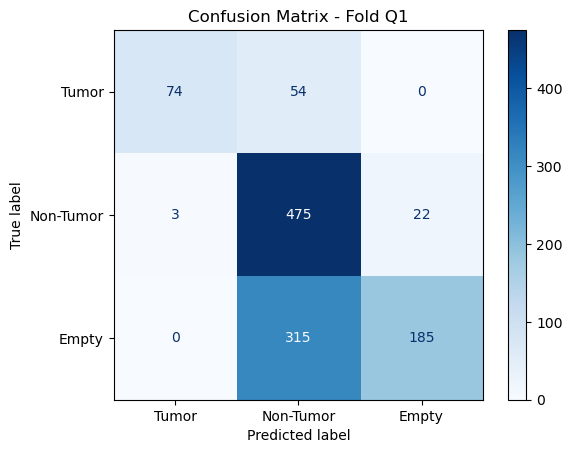


— Fold: Q2 —
Epoch 1/10 - Train Loss: 0.8476
Epoch 2/10 - Train Loss: 0.7589
Epoch 3/10 - Train Loss: 0.7132
Epoch 4/10 - Train Loss: 0.6807
Epoch 5/10 - Train Loss: 0.6843
Epoch 6/10 - Train Loss: 0.6783
Epoch 7/10 - Train Loss: 0.6565
Epoch 8/10 - Train Loss: 0.6630
Epoch 9/10 - Train Loss: 0.6571
Epoch 10/10 - Train Loss: 0.6399
Model saved to trained_model_fold_Q2.pth
Accuracy: 0.7066, F1-score: 0.7043
              precision    recall  f1-score   support

       Tumor       0.83      0.59      0.69       128
   Non-Tumor       0.70      0.64      0.67       500
       Empty       0.69      0.80      0.74       500

    accuracy                           0.71      1128
   macro avg       0.74      0.68      0.70      1128
weighted avg       0.71      0.71      0.70      1128



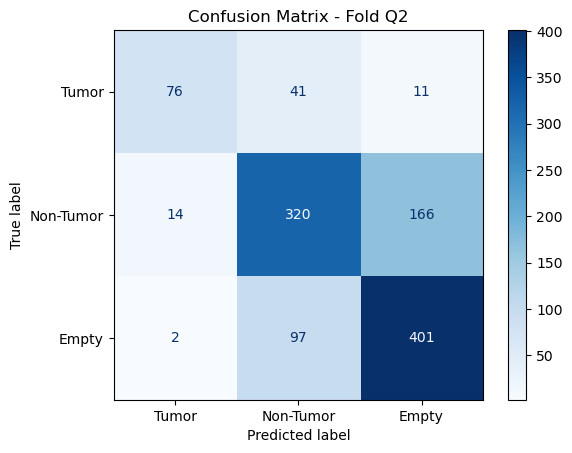


— Fold: Q3 —
Epoch 1/10 - Train Loss: 0.8108
Epoch 2/10 - Train Loss: 0.7245
Epoch 3/10 - Train Loss: 0.6915
Epoch 4/10 - Train Loss: 0.6925
Epoch 5/10 - Train Loss: 0.6680
Epoch 6/10 - Train Loss: 0.6704
Epoch 7/10 - Train Loss: 0.6502
Epoch 8/10 - Train Loss: 0.6473
Epoch 9/10 - Train Loss: 0.6406
Epoch 10/10 - Train Loss: 0.6239
Model saved to trained_model_fold_Q3.pth
Accuracy: 0.6809, F1-score: 0.6789
              precision    recall  f1-score   support

       Tumor       0.91      0.56      0.70       128
   Non-Tumor       0.66      0.61      0.64       500
       Empty       0.66      0.78      0.72       500

    accuracy                           0.68      1128
   macro avg       0.75      0.65      0.68      1128
weighted avg       0.69      0.68      0.68      1128



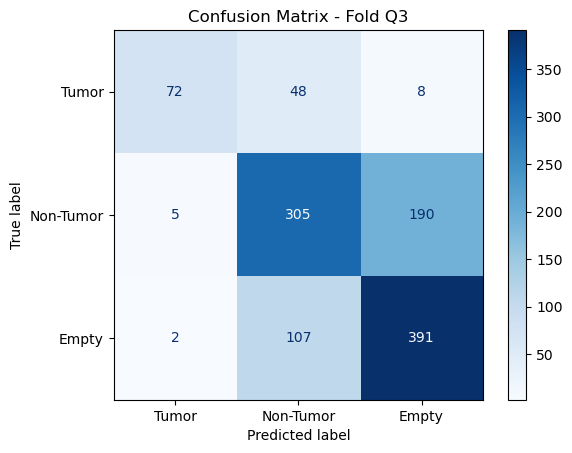


— Fold: Q4 —
Epoch 1/10 - Train Loss: 0.8733
Epoch 2/10 - Train Loss: 0.7540
Epoch 3/10 - Train Loss: 0.7089
Epoch 4/10 - Train Loss: 0.6893
Epoch 5/10 - Train Loss: 0.6846
Epoch 6/10 - Train Loss: 0.6790
Epoch 7/10 - Train Loss: 0.6443
Epoch 8/10 - Train Loss: 0.6352
Epoch 9/10 - Train Loss: 0.6225
Epoch 10/10 - Train Loss: 0.6228
Model saved to trained_model_fold_Q4.pth
Accuracy: 0.6817, F1-score: 0.6808
              precision    recall  f1-score   support

       Tumor       0.67      0.52      0.58       128
   Non-Tumor       0.65      0.70      0.67       500
       Empty       0.72      0.71      0.71       500

    accuracy                           0.68      1128
   macro avg       0.68      0.64      0.66      1128
weighted avg       0.68      0.68      0.68      1128



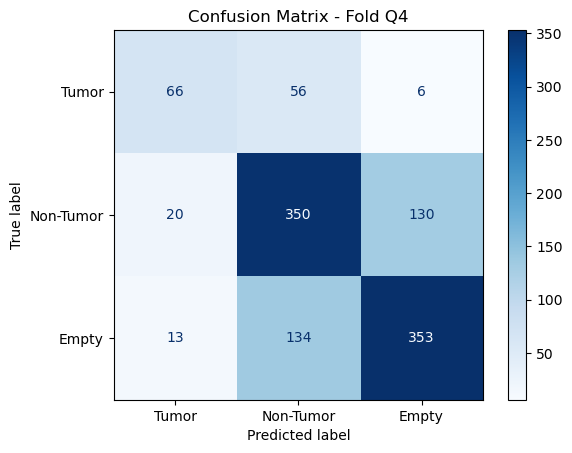

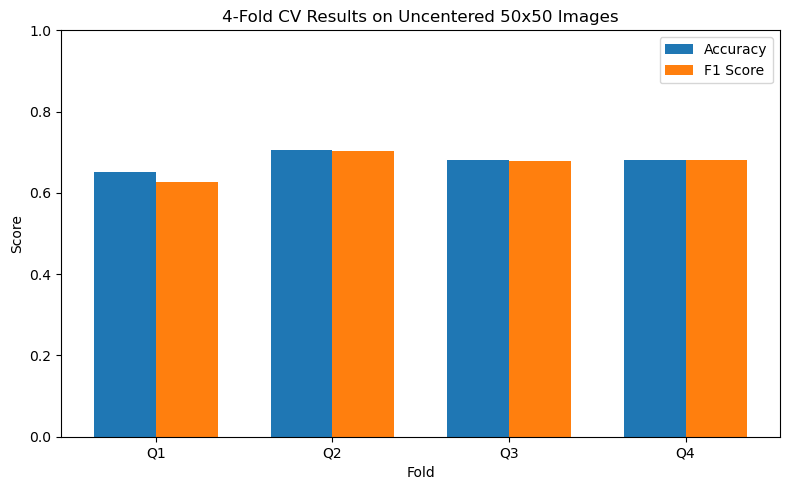

In [10]:
accuracies = []
f1_scores = []

# Create a directory to save reports if it doesn't exist
report_dir = './Output_50_both_uncentered'
os.makedirs(report_dir, exist_ok=True)

for fold in FOLDS:
    print(f"\n— Fold: {fold} —")
    
    train_loader, test_loader = get_dataloaders_for_fold(fold)

    model = SimpleCNN(num_classes=NUM_CLASSES).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(EPOCHS):
        train_loss = train(model, train_loader, optimizer, criterion)
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}")

    torch.save(model.state_dict(), f"trained_model_fold_{fold}.pth")
    print(f"Model saved to trained_model_fold_{fold}.pth")

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    accuracies.append(acc)
    f1_scores.append(f1)

    print(f"Accuracy: {acc:.4f}, F1-score: {f1:.4f}")

    # Save classification report to a text file
    report_filename = os.path.join(report_dir, f"classification_report_fold_{fold}.txt")
    with open(report_filename, 'w') as report_file:
        report_file.write(f"Classification Report - Fold {fold}\n\n")
        report_file.write(classification_report(y_true, y_pred, target_names=CLASSES))

    # Print classification report to console
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    # Display confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.show()


# Plot bar chart for accuracy and F1-score
x = FOLDS
bar_width = 0.35
x_idx = np.arange(len(x))

plt.figure(figsize=(8, 5))
plt.bar(x_idx, accuracies, bar_width, label='Accuracy')
plt.bar(x_idx + bar_width, f1_scores, bar_width, label='F1 Score')
plt.xticks(x_idx + bar_width / 2, x)
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('4-Fold CV Results on Uncentered 50x50 Images')
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()